# Tracer mass requirement with fixed injection time

This notebook simulates single-porosity two-component curves for a fixed fracture retardation factor (`R_f = 3.5`) with fixed injection duration (`1.5 hr`) and varying tracer mass.

Injection concentration is computed from:

```text
C = M / V
V = q_inj * t
```

with unit conversions so `C` is in `mg/L`.

For each simulated curve:
- Background concentration is fixed at `22 mg/L`.
- Absolute concentration is defined as `C_eq(t) = C_eq,R(t) + C0`, then plotted versus time.


## 1) Imports

In [18]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2) Read required inputs

In [19]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity

best_csv = repo_root / "two_components/outputs/phase_exploitation/overall_best_refined_solution.csv"
best_df = pd.read_csv(best_csv)
best_row = best_df.loc[best_df["best_J"].idxmin()]

mrt1_best = float(best_row["best_MRT1"])
mrt2_best = float(best_row["best_MRT2"])
pe1_best = float(best_row["best_Pe1"])
pe2_best = float(best_row["best_Pe2"])
fr1_best = float(best_row["best_fr1"])
fr2_best = float(best_row["best_fr2"])

best_df.head()

,basin_id,ref_run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,best_J,nit,nfev,success,message
0,19,2,202,11.475848,48.819593,15.32661,2.034558,0.265815,0.671666,0.030909,59,5387,True,Optimization terminated successfully.


## 3) Define single-run model

In [20]:
def modelRELAP_single_duration(
    t,
    mrt,
    pec,
    fracture_retardation,
    bckgrnd_conc,
    inj_duration_hr,
    inj_concentration_mgL,
):
    inj_concs = np.array([inj_concentration_mgL, bckgrnd_conc], dtype=float)
    inj_durs = np.cumsum(np.array([inj_duration_hr], dtype=float))
    dpParam = 0.0
    matrix_retardation = 1.0
    recRatio = 0.0
    wsCoef = 0.0

    return np.asarray(
        simulateDualPorosity(
            mrt,
            pec,
            fracture_retardation,
            t,
            bckgrnd_conc,
            inj_concs,
            inj_durs,
            dpParam,
            matrix_retardation,
            recRatio=recRatio,
            wsCoef=wsCoef,
            delay_time=0,
        ),
        dtype=float,
    )

## 4) Simulate fixed-duration cases with varying tracer mass

In [41]:
fracture_retardation = 3.5
background_concentration = 22.0
t_plot = np.linspace(0.1, 130.0, 100)

fixed_injection_duration_hr = 1.5
masses_kg = [5.0, 10.0, 25.0, 50.0, 75.0, 100.0, 115.0]
q_inj_bbl_min = 10.0
bbl_to_L = 158.987294928

injected_volume_L = q_inj_bbl_min * 60.0 * fixed_injection_duration_hr * bbl_to_L

results = {}
summary_rows = []

for mass_kg in masses_kg:
    inj_concentration_mgL = mass_kg * 1e6 / injected_volume_L

    c1_100 = modelRELAP_single_duration(
        t_plot,
        mrt1_best,
        pe1_best,
        fracture_retardation,
        background_concentration,
        fixed_injection_duration_hr,
        inj_concentration_mgL,
    )
    c2_100 = modelRELAP_single_duration(
        t_plot,
        mrt2_best,
        pe2_best,
        fracture_retardation,
        background_concentration,
        fixed_injection_duration_hr,
        inj_concentration_mgL,
    )

    c1_rel = c1_100 - background_concentration
    c2_rel = c2_100 - background_concentration
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
    c_eq = c_eq_rel + background_concentration

    results[mass_kg] = {
        "mass_kg": mass_kg,
        "C_eq": c_eq,
        "inj_concentration_mgL": inj_concentration_mgL,
    }

    summary_rows.append(
        {
            "mass_kg": mass_kg,
            "inj_concentration_mgL": inj_concentration_mgL,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("mass_kg").reset_index(drop=True)
summary_df

,mass_kg,inj_concentration_mgL
0,5.0,34.943393
1,10.0,69.886786
2,25.0,174.716966
3,50.0,349.433932
4,75.0,524.150898
5,100.0,698.867863
6,115.0,803.698043


## 5) Plot all simulated curves (legend = tracer mass)

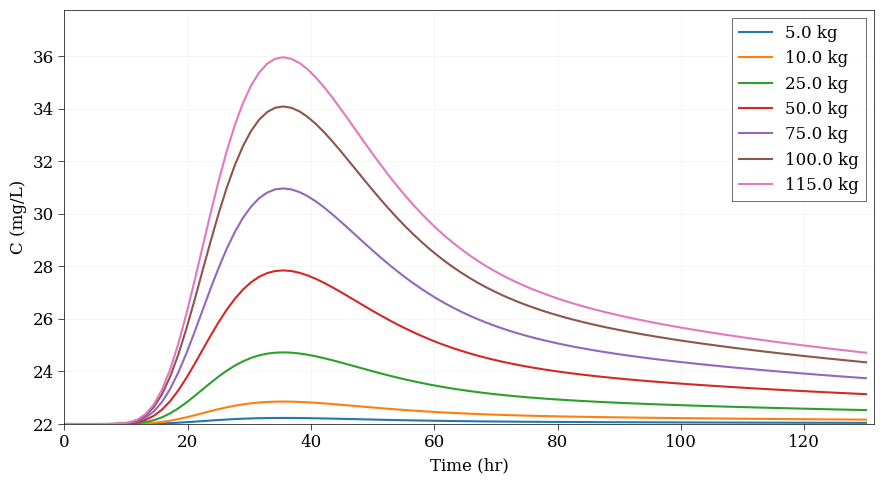

In [42]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for mass_kg in masses_kg:
        ax.plot(
            t_plot,
            results[mass_kg]["C_eq"],
            linewidth=_pt,
            label=f"{mass_kg:.1f} kg",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_max = max(np.max(results[m]["C_eq"]) for m in masses_kg)
    ax.set_xlim(0, float(np.max(t_plot)) * 1.01)
    ax.set_ylim(float(background_concentration), float(y_max) * 1.05)

    leg = ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg.get_frame().set_linewidth(_pt_hair)

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/tracer_mass_required_single_porosity_rf_3p5.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [43]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

btc_export = pd.DataFrame({"time_hr": t_plot})
for mass_kg in masses_kg:
    mass_tag = f"{mass_kg:.1f}".replace(".", "p")
    btc_export[f"C_eq_mgL_mass_{mass_tag}_kg"] = results[mass_kg]["C_eq"]

btc_export_path = tabular_results_dir / "tracer_mass_required_single_porosity_rf_3p5.xlsx"
btc_export.to_excel(btc_export_path, index=False)
btc_export_path

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/tracer_mass_required_single_porosity_rf_3p5.xlsx')

## 6) Requirement check using percentile from uniform(`C_min`, `C_max`)

For each tracer breakthrough curve (fixed duration, varying mass):

- Compute `C_min` and `C_max` from `C_eq(t)`.
- Assume a uniform distribution over `[C_min, C_max]`.
- Compute the controllable percentile `p_percentile` and use it as `C_ref`.
- Evaluate the requirement:

```text
C_ref * (1 - 1.96 / SNR) - C_0 >= beta
```

where `SNR = 10`, `C_0 = 22 mg/L`, and `beta = 0.1 mg/L`.

In [46]:
p_percentile = 50.0  # controllable percentile
SNR = 10.0
beta = 0.1

requirement_rows = []

for mass_kg in masses_kg:
    c_curve = results[mass_kg]["C_eq"]
    c_min = float(np.min(c_curve))
    c_max = float(np.max(c_curve))

    c_ref = c_min + (p_percentile / 100.0) * (c_max - c_min)
    ci_interval = (1.96 / SNR) * c_ref
    lhs = c_ref * (1.0 - 1.96 / SNR) - background_concentration
    meets_requirement = lhs >= beta

    requirement_rows.append(
        {
            "mass_kg": mass_kg,
            "C_min_mgL": c_min,
            "C_max_mgL": c_max,
            "C_ref_mgL": c_ref,
            "CI_interval_mgL": ci_interval,
            "meets_requirement": meets_requirement,
        }
    )

requirement_df = pd.DataFrame(requirement_rows).sort_values("mass_kg").reset_index(drop=True)
requirement_df.to_excel(tabular_results_dir / "tracer_mass_required_single_porosity_rf_3p5_percentile_50_snr10_beta0p1.xlsx", index=False)
requirement_df

,mass_kg,C_min_mgL,C_max_mgL,C_ref_mgL,CI_interval_mgL,meets_requirement
0,5.0,22.0,22.231058,22.115529,4.334644,False
1,10.0,22.0,22.854847,22.427424,4.395775,False
2,25.0,22.0,24.726215,23.363107,4.579169,False
3,50.0,22.0,27.845161,24.922580,4.884826,False
4,75.0,22.0,30.964107,26.482053,5.190482,False
5,100.0,22.0,34.083053,28.041526,5.496139,True
6,115.0,22.0,35.954420,28.977210,5.679533,True


In [24]:
mass_meeting_requirement = requirement_df.loc[requirement_df["meets_requirement"], "mass_kg"]
minimum_mass_meeting_requirement_kg = mass_meeting_requirement.min() if len(mass_meeting_requirement) > 0 else np.nan

minimum_mass_meeting_requirement_kg

100.0

In [25]:
def find_required_mass_kg_0p1(
    p_percentile,
    SNR,
    beta,
    background_concentration,
    fracture_retardation,
    mass_start_kg=10.0,
    fixed_injection_duration_hr=1.5,
    q_inj_bbl_min=10.0,
    bbl_to_L=158.987294928,
    t_plot=None,
    max_search_mass_kg=5000.0,
):
    if t_plot is None:
        t_plot = np.linspace(0.1, 130.0, 250)

    injected_volume_L = q_inj_bbl_min * 60.0 * fixed_injection_duration_hr * bbl_to_L

    def evaluate_mass(mass_kg):
        inj_concentration_mgL = mass_kg * 1e6 / injected_volume_L

        c1_100 = modelRELAP_single_duration(
            t_plot,
            mrt1_best,
            pe1_best,
            fracture_retardation,
            background_concentration,
            fixed_injection_duration_hr,
            inj_concentration_mgL,
        )
        c2_100 = modelRELAP_single_duration(
            t_plot,
            mrt2_best,
            pe2_best,
            fracture_retardation,
            background_concentration,
            fixed_injection_duration_hr,
            inj_concentration_mgL,
        )

        c1_rel = c1_100 - background_concentration
        c2_rel = c2_100 - background_concentration
        c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
        c_eq = c_eq_rel + background_concentration

        c_min = float(np.min(c_eq))
        c_max = float(np.max(c_eq))
        c_ref = c_min + (p_percentile / 100.0) * (c_max - c_min)

        lhs = c_ref * (1.0 - 1.96 / SNR) - background_concentration
        meets_requirement = lhs >= beta

        return meets_requirement, {
            "mass_kg": round(mass_kg, 1),
            "inj_concentration_mgL": inj_concentration_mgL,
            "C_min_mgL": c_min,
            "C_max_mgL": c_max,
            "C_ref_mgL": c_ref,
            "lhs_mgL": lhs,
            "meets_requirement": meets_requirement,
        }

    low_idx = 0
    high_idx = max(1, int(round(mass_start_kg * 10)))

    meets, details = evaluate_mass(high_idx / 10.0)
    while not meets:
        high_idx *= 2
        if high_idx / 10.0 > max_search_mass_kg:
            return {
                "mass_kg": np.nan,
                "meets_requirement": False,
                "reason": "max_search_mass_kg_reached",
            }
        meets, details = evaluate_mass(high_idx / 10.0)

    while high_idx - low_idx > 1:
        mid_idx = (low_idx + high_idx) // 2
        mid_meets, _ = evaluate_mass(mid_idx / 10.0)
        if mid_meets:
            high_idx = mid_idx
        else:
            low_idx = mid_idx

    _, best_details = evaluate_mass(high_idx / 10.0)
    return best_details


# Example usage:
# required_mass_result = find_required_mass_kg_0p1(
#     p_percentile=50.0,
#     SNR=10.0,
#     beta=0.1,
#     background_concentration=background_concentration,
#     fracture_retardation=fracture_retardation,
#     mass_start_kg=10.0,
# )
# required_mass_result

In [26]:
rf_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

p_percentile_target = 50.0
SNR_target = 10.0
beta_target = 0.1
background_target = 22.0

required_mass_rows = []

for rf in rf_values:
    result = find_required_mass_kg_0p1(
        p_percentile=p_percentile_target,
        SNR=SNR_target,
        beta=beta_target,
        background_concentration=background_target,
        fracture_retardation=rf,
        mass_start_kg=10.0,
        fixed_injection_duration_hr=fixed_injection_duration_hr,
        q_inj_bbl_min=q_inj_bbl_min,
        bbl_to_L=bbl_to_L,
        t_plot=t_plot,
    )

    required_mass_rows.append(
        {
            "fracture_retardation": rf,
            "required_mass_kg": result["mass_kg"],
        }
    )

required_mass_df = pd.DataFrame(required_mass_rows)
required_mass_df

,fracture_retardation,required_mass_kg
0,1.5,41.0
1,2.0,53.5
2,2.5,66.1
3,3.0,78.6
4,3.5,91.2
5,4.0,103.7


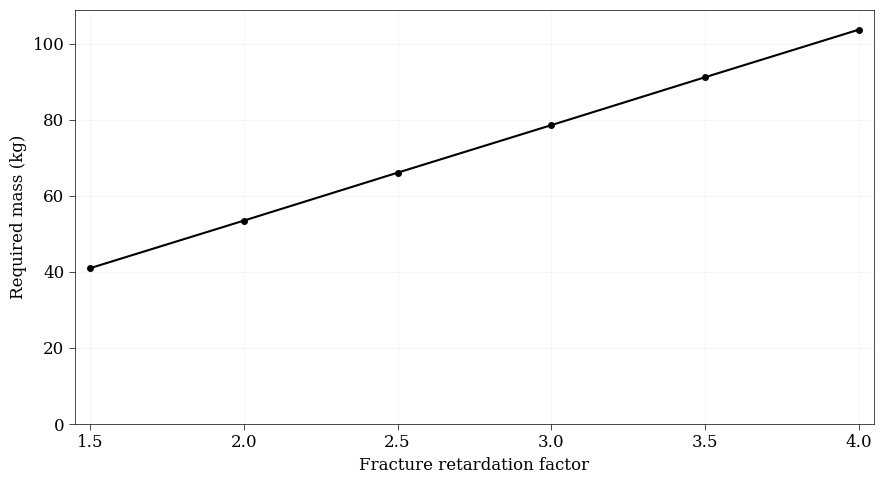

In [27]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    ax.plot(
        required_mass_df["fracture_retardation"],
        required_mass_df["required_mass_kg"],
        color="black",
        linewidth=_pt,
        marker="o",
        markersize=4,
    )

    ax.set_xlabel("Fracture retardation factor")
    ax.set_ylabel("Required mass (kg)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    ax.set_xlim(min(rf_values) - 0.05, max(rf_values) + 0.05)
    y_max = float(np.nanmax(required_mass_df["required_mass_kg"]))
    ax.set_ylim(0, y_max * 1.05)

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/required_mass_vs_fracture_retardation.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [47]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

required_mass_export_path = tabular_results_dir / "required_mass_vs_fracture_retardation_p50_snr10_beta0p1_c0_22.xlsx"
required_mass_df.to_excel(required_mass_export_path, index=False)
required_mass_export_path

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/required_mass_vs_fracture_retardation_p50_snr10_beta0p1_c0_22.xlsx')

## 9) Monte Carlo uncertainty in required tracer mass

Quantify how uncertainty in the calibrated fluid-flow parameters (`MRT1`, `MRT2`, `Pe1`, `Pe2`, `fr1`, `fr2`) propagates into the required tracer mass.

- Fixed inputs: `p_percentile = 50`, `SNR = 10`, `beta = 1 mg/L`, `R_f = 3.5`, `C0 = 22 mg/L`, `t_inj = 1.5 hr`, `q_inj = 10 bbl/min`.
- Source: `two_components/outputs/phase_exploration/exploration_ensemble.csv`.
- Each parameter column is independently bootstrapped (sampling with replacement) to draw 1000 values, then the columns are combined index-wise into 1000 parameter sets.
- For each parameter set, the minimum required tracer mass (0.1 kg resolution) is found via the same exponential-bracketing plus binary-search procedure used in `find_required_mass_kg_0p1`.
- The resulting 1000 required-mass values are visualized as a journal-style histogram.

In [28]:
try:
    from tqdm.auto import tqdm
    _has_tqdm = True
except ImportError:
    _has_tqdm = False
    def tqdm(iterable, **kwargs):
        return iterable

mc_p_percentile = 50.0
mc_SNR = 10.0
mc_beta = 1.0
mc_fracture_retardation = 3.5
mc_background_concentration = 22.0
mc_fixed_injection_duration_hr = 1.5
mc_q_inj_bbl_min = 10.0
mc_bbl_to_L = 158.987294928
mc_t_plot = np.linspace(0.1, 130.0, 250)
mc_n_samples = 1000
mc_seed = 20260424

ensemble_path = repo_root / "two_components" / "outputs" / "phase_exploration" / "exploration_ensemble.csv"
ensemble_df = pd.read_csv(ensemble_path)

rng = np.random.default_rng(mc_seed)
sampled_MRT1 = rng.choice(ensemble_df["best_MRT1"].to_numpy(), size=mc_n_samples, replace=True)
sampled_MRT2 = rng.choice(ensemble_df["best_MRT2"].to_numpy(), size=mc_n_samples, replace=True)
sampled_Pe1 = rng.choice(ensemble_df["best_Pe1"].to_numpy(), size=mc_n_samples, replace=True)
sampled_Pe2 = rng.choice(ensemble_df["best_Pe2"].to_numpy(), size=mc_n_samples, replace=True)
sampled_fr1 = rng.choice(ensemble_df["best_fr1"].to_numpy(), size=mc_n_samples, replace=True)
sampled_fr2 = rng.choice(ensemble_df["best_fr2"].to_numpy(), size=mc_n_samples, replace=True)

mc_injected_volume_L = mc_q_inj_bbl_min * 60.0 * mc_fixed_injection_duration_hr * mc_bbl_to_L


def _required_mass_for_sample(
    mrt1_s,
    mrt2_s,
    pe1_s,
    pe2_s,
    fr1_s,
    fr2_s,
    mass_start_kg=10.0,
    max_search_mass_kg=5000.0,
):
    def evaluate_mass(mass_kg):
        inj_concentration_mgL = mass_kg * 1e6 / mc_injected_volume_L

        c1_100 = modelRELAP_single_duration(
            mc_t_plot,
            mrt1_s,
            pe1_s,
            mc_fracture_retardation,
            mc_background_concentration,
            mc_fixed_injection_duration_hr,
            inj_concentration_mgL,
        )
        c2_100 = modelRELAP_single_duration(
            mc_t_plot,
            mrt2_s,
            pe2_s,
            mc_fracture_retardation,
            mc_background_concentration,
            mc_fixed_injection_duration_hr,
            inj_concentration_mgL,
        )

        c1_rel = c1_100 - mc_background_concentration
        c2_rel = c2_100 - mc_background_concentration
        c_eq_rel = fr1_s * c1_rel + fr2_s * c2_rel
        c_eq = c_eq_rel + mc_background_concentration

        c_min = float(np.min(c_eq))
        c_max = float(np.max(c_eq))
        c_ref = c_min + (mc_p_percentile / 100.0) * (c_max - c_min)

        lhs = c_ref * (1.0 - 1.96 / mc_SNR) - mc_background_concentration
        return lhs >= mc_beta

    low_idx = 0
    high_idx = max(1, int(round(mass_start_kg * 10)))

    if not evaluate_mass(high_idx / 10.0):
        while True:
            high_idx *= 2
            if high_idx / 10.0 > max_search_mass_kg:
                return float("nan")
            if evaluate_mass(high_idx / 10.0):
                break

    while high_idx - low_idx > 1:
        mid_idx = (low_idx + high_idx) // 2
        if evaluate_mass(mid_idx / 10.0):
            high_idx = mid_idx
        else:
            low_idx = mid_idx

    return round(high_idx / 10.0, 1)


required_mass_samples = np.empty(mc_n_samples, dtype=float)

for i in tqdm(range(mc_n_samples), desc="Monte Carlo required mass"):
    required_mass_samples[i] = _required_mass_for_sample(
        sampled_MRT1[i],
        sampled_MRT2[i],
        sampled_Pe1[i],
        sampled_Pe2[i],
        sampled_fr1[i],
        sampled_fr2[i],
    )

mc_required_mass_df = pd.DataFrame(
    {
        "MRT1": sampled_MRT1,
        "MRT2": sampled_MRT2,
        "Pe1": sampled_Pe1,
        "Pe2": sampled_Pe2,
        "fr1": sampled_fr1,
        "fr2": sampled_fr2,
        "required_mass_kg": required_mass_samples,
    }
)

mc_required_mass_df.describe()

/home/mabdellatif_laptop/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Monte Carlo required mass: 100%|██████████| 1000/1000 [28:10<00:00,  1.69s/it]


,MRT1,MRT2,Pe1,Pe2,fr1,fr2,required_mass_kg
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,11.595310,49.322222,14.358250,2.290918,0.294392,0.635758,110.308400
std,0.118586,1.523361,0.736337,0.216950,0.021684,0.025941,7.376315
min,11.289658,44.558905,12.748157,1.746895,0.230560,0.568407,92.000000
25%,11.510486,48.220735,13.815770,2.135988,0.280232,0.616582,105.200000
50%,11.592701,49.373153,14.304158,2.297399,0.295826,0.634142,109.700000
75%,11.676383,50.353832,14.826933,2.439091,0.307931,0.651777,114.600000
max,11.990757,53.753453,17.309234,2.898093,0.353853,0.723126,144.500000


Mean required mass:   110.31 kg
Median required mass: 109.70 kg
Std required mass:    7.38 kg


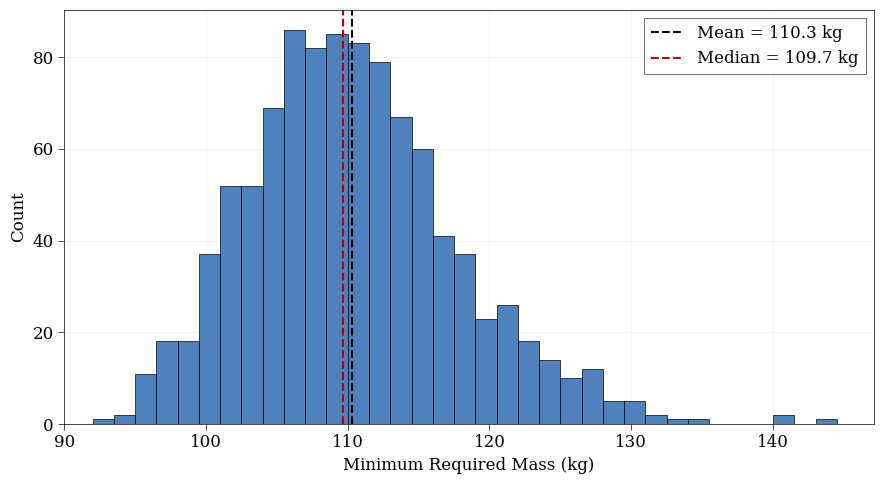

In [51]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    finite_mass = mc_required_mass_df["required_mass_kg"].dropna().to_numpy()

    mean_mass = float(np.mean(finite_mass))
    median_mass = float(np.median(finite_mass))
    std_mass = float(np.std(finite_mass, ddof=1))

    print(f"Mean required mass:   {mean_mass:.2f} kg")
    print(f"Median required mass: {median_mass:.2f} kg")
    print(f"Std required mass:    {std_mass:.2f} kg")

    ax.hist(
        finite_mass,
        bins=35,
        color="#4F81BD",
        edgecolor="black",
        linewidth=_pt_hair,
    )

    ax.axvline(
        mean_mass,
        color="black",
        linestyle="--",
        linewidth=_pt,
        label=f"Mean = {mean_mass:.1f} kg",
    )
    ax.axvline(
        median_mass,
        color="#C00000",
        linestyle="--",
        linewidth=_pt,
        label=f"Median = {median_mass:.1f} kg",
    )

    ax.set_xlabel("Minimum Required Mass (kg)")
    ax.set_ylabel("Count")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    ax.set_xlim(left=90)

    leg = ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg.get_frame().set_linewidth(_pt_hair)

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    fig.savefig(
        "../Figures/required_mass_monte_carlo_histogram.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()

In [30]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

mc_required_mass_csv_path = tabular_results_dir / "monte_carlo_required_mass_rf_3p5_c0_22_snr10_beta1_p50.csv"
mc_required_mass_df.to_csv(mc_required_mass_csv_path, index=False)
mc_required_mass_csv_path

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/monte_carlo_required_mass_rf_3p5_c0_22_snr10_beta1_p50.csv')